# CallMeMaybe Detección de Operadores Ineficaces


## Introducción y Objetivo del Proyecto
**El servicio de telefonía virtual CallMeMaybe busca desarrollar una funcionalidad que permita identificar operadores ineficaces dentro de su sistema de atención telefónica.**

**Para ello, se analizarán registros históricos de llamadas con el objetivo de detectar patrones relacionados con:**
**llamadas perdidas, tiempos elevados de espera, y cantidad de llamadas salientes y entrantes.**

**A través de análisis exploratorio de datos, métricas de desempeño y pruebas estadísticas, el proyecto busca identificar comportamientos asociados a ineficacia operativa y generar insights útiles para supervisión y toma de decisiones.**

## Descripción de los datos

Los datasets contienen información sobre el uso del servicio de telefonía virtual CallMeMaybe. Sus clientes son organizaciones que necesitan distribuir gran cantidad de llamadas entrantes entre varios operadores, o realizar llamadas salientes a través de sus operadores. Los operadores también pueden realizar llamadas internas para comunicarse entre ellos. Estas llamadas se realizan a través de la red de CallMeMaybe.

El dataset `telecom_dataset_us.csv` contiene las siguientes columnas:
- `user_id`: ID de la cuenta de cliente
- `date`: fecha en la que se recuperaron las estadísticas
- `direction`: "dirección" de llamada (`out` para saliente, `in` para entrante)
- `internal`: si la llamada fue interna (entre los operadores de un cliente o clienta)
- `operator_id`: identificador del operador
- `is_missed_call`: si fue una llamada perdida
- `calls_count`: número de llamadas
- `call_duration`: duración de la llamada (sin incluir el tiempo de espera)
- `total_call_duration`: duración de la llamada (incluido el tiempo de espera)

 

El conjunto de datos `telecom_clients_us.csv` tiene las siguientes columnas:
- `user_id`: ID de usuario/a
- `tariff_plan`: tarifa actual de la clientela
- `date_start`: fecha de registro de la clientela

## Carga y preparación de datos

### Inicialización

In [1]:
# Importación de librerías

# Importar Librerías
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import shapiro
from scipy.stats import mannwhitneyu

In [2]:
# Carga de datasets
dataset = pd.read_csv('telecom_dataset_new.csv')
clients = pd.read_csv('telecom_clients.csv')

### Exploración inicial

In [3]:
# Imprimir dimensiones de dataset "dataset"
print(dataset.shape)

(53902, 9)


In [4]:
# Imprimir primeras filas de dataset "dataset"
print(dataset.head(3))

   user_id                       date  ... call_duration total_call_duration
0   166377  2019-08-04 00:00:00+03:00  ...             0                   4
1   166377  2019-08-05 00:00:00+03:00  ...             0                   5
2   166377  2019-08-05 00:00:00+03:00  ...             0                   1

[3 rows x 9 columns]


In [5]:
# Revisión de tipos de datos de dataset "dataset"
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


<div style="border-left: 10px solid #616161;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

- Se observa que la columna `internal` tiene el tipo de dato `object`, aunque por la naturaleza de sus valores se esperaría un tipo booleano (`bool`). Debido a esta discrepancia, se realizó un análisis para identificar la causa y determinar si era necesario convertir su tipo de dato.

</div>


In [6]:
# Filtrar filas con valores ausentes en la columna "internal"
dataset[dataset['internal'].isna()]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
1007,166405,2019-09-18 00:00:00+03:00,in,NaN,NaN,True,1,0,59
1090,166405,2019-10-01 00:00:00+03:00,in,NaN,NaN,True,1,0,1
1864,166406,2019-08-20 00:00:00+03:00,in,NaN,NaN,True,1,0,36
1924,166406,2019-09-02 00:00:00+03:00,in,NaN,879898.0,False,1,2,9
6210,166541,2019-09-26 00:00:00+03:00,in,NaN,908960.0,False,1,393,423
...,...,...,...,...,...,...,...,...,...
52462,168361,2019-11-09 00:00:00+03:00,in,NaN,NaN,True,6,0,14
52590,168361,2019-11-13 00:00:00+03:00,in,NaN,NaN,True,2,0,6
52621,168361,2019-11-14 00:00:00+03:00,in,NaN,NaN,True,1,0,2
53717,168579,2019-11-09 00:00:00+03:00,in,NaN,NaN,True,1,0,18


In [7]:
# Filtrar valores únicos en la columna "direction" para filas con valores ausentes en "internal"
dataset.loc[dataset['internal'].isna(), 'direction'].unique()

array(['in', 'out'], dtype=object)

In [8]:
# Filtrar filas con valores ausentes en "internal" y dirección "out"
dataset.loc[
    (dataset['internal'].isna()) & (dataset['direction'] == 'out')
]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
21004,167016,2019-10-23 00:00:00+03:00,out,NaN,NaN,True,3,0,196
51367,168291,2019-11-28 00:00:00+03:00,out,NaN,NaN,True,3,0,93


<div style="border-left: 10px solid #616161;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

- La variable internal fue cargada como tipo object debido a la presencia de 117 valores ausentes. Al inspeccionar estos registros se observó que la mayoría corresponden a llamadas entrantes y solo dos registros a llamadas salientes. La presencia de valores nulos impide que Pandas reconozca automáticamente la columna como booleana, aunque conceptualmente la variable representa una condición binaria (True o False).
Por este motivo, la variable se mantendrá temporalmente como tipo object hasta determinar el tratamiento adecuado de los valores ausentes durante la etapa de preprocesamiento.

</div>


In [9]:
# Busqueda de valores ausentes en dataset "dataset"
print(dataset.isnull().sum())

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64


<div style="border-left: 10px solid #616161;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

- Se identificaron valores ausentes únicamente en las columnas internal y operator_id, mientras que el resto de las variables se encuentran completas. Debido a que ambas columnas podrían afectar el análisis posterior, se revisarán con mayor detalle durante el preprocesamiento.

</div>


In [10]:
# Búsqueda de duplicados en dataset "dataset"
print(dataset.duplicated().sum())

4900


<div style="border-left: 10px solid #616161;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

- Se identificaron 4900 registros duplicados en el dataset principal. Debido a que se trata de un número considerable de observaciones, será necesario verificar si corresponden a duplicados reales o si representan múltiples registros válidos generados por el sistema antes de decidir su tratamiento durante el preprocesamiento.

</div>


In [11]:
# Imprimir dimensiones de dataset "clients"
print(clients.shape)

(732, 3)


In [12]:
# Imprimir primeras filas de dataset "clients"
print(clients.head(3))

   user_id tariff_plan  date_start
0   166713           A  2019-08-15
1   166901           A  2019-08-23
2   168527           A  2019-10-29


In [13]:
# Revisión de tipos de datos de dataset "clients"
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


In [14]:
# Busqueda de valores ausentes en dataset "clients"
print(clients.isnull().sum())

user_id        0
tariff_plan    0
date_start     0
dtype: int64


In [15]:
# Búsqueda de duplicados en dataset "clients"
print(clients.duplicated().sum())

0


<div style="border-left: 10px solid #616161;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

- El tipo de datos de `date_start` debe cambiarse, actualmente no es correcto pues aparece como object y deberia de ser fecha.

</div>




## Preprocesamiento

In [16]:
# limpieza básica
# creación de métricas tiempo de espera y tasa de llamadas perdidas

In [17]:
# conversión de fechas
dataset['date'] = pd.to_datetime(dataset['date'])
clients['date_start'] = pd.to_datetime(clients['date_start'])

In [18]:
# Manejo de duplicados exactos en dataset "dataset"
dataset = dataset.drop_duplicates()
# Verificar que no hay duplicados exactos nuevamente
print(dataset.duplicated().sum())

0


In [19]:
# unión de datasets
all_data = pd.merge(dataset, clients, how='left', on='user_id')

In [20]:
# Creación de métrica "waiting_time" (tiempo de espera) en segundos
all_data['waiting_time'] = all_data['total_call_duration'] - \
    all_data['call_duration']

# Creación de métrica de tiempo promedio de espera por llamada "avg_waiting_time"
all_data['avg_waiting_time'] = (
    all_data['waiting_time']
    / all_data['calls_count']
)

# Duración promedio de conversación por llamada "avg_call_duration"
all_data['avg_call_duration'] = (
    all_data['call_duration']
    / all_data['calls_count']
)
all_data

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,tariff_plan,date_start,waiting_time,avg_waiting_time,avg_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4,B,2019-08-01,4,2.000000,0.0
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5,B,2019-08-01,5,1.666667,0.0
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1,B,2019-08-01,1,1.000000,0.0
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18,B,2019-08-01,8,8.000000,10.0
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25,B,2019-08-01,25,8.333333,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48997,168606,2019-11-10 00:00:00+03:00,out,True,957922.0,False,1,0,25,C,2019-10-31,25,25.000000,0.0
48998,168606,2019-11-10 00:00:00+03:00,out,True,957922.0,True,1,0,38,C,2019-10-31,38,38.000000,0.0
48999,168606,2019-11-11 00:00:00+03:00,out,True,957922.0,False,2,479,501,C,2019-10-31,22,11.000000,239.5
49000,168606,2019-11-15 00:00:00+03:00,out,True,957922.0,False,4,3130,3190,C,2019-10-31,60,15.000000,782.5


In [21]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49002 entries, 0 to 49001
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   user_id              49002 non-null  int64                    
 1   date                 49002 non-null  datetime64[ns, UTC+03:00]
 2   direction            49002 non-null  object                   
 3   internal             48892 non-null  object                   
 4   operator_id          41546 non-null  float64                  
 5   is_missed_call       49002 non-null  bool                     
 6   calls_count          49002 non-null  int64                    
 7   call_duration        49002 non-null  int64                    
 8   total_call_duration  49002 non-null  int64                    
 9   tariff_plan          49002 non-null  object                   
 10  date_start           49002 non-null  datetime64[ns]           
 11  wa

<div style="border-left: 10px solid #616161;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

## Conclusiones Preprocesamiento
- Tras el preprocesamiento, las columnas de fecha fueron convertidas al tipo de dato adecuado, se eliminaron los registros duplicados exactos, se integró la información de ambos datasets y se creó la variable `waiting_time` para representar el tiempo de espera real de las llamadas. Los valores ausentes en `internal` y `operator_id` se conservaron, ya que su tratamiento requiere considerar el contexto del análisis para evitar la pérdida de información relevante.
- También se creó un archivo con las datos limpios para poder crear el dashboard de manera eficiente.

</div>



## 1. Análisis exploratorio de datos (EDA)

El objetivo de esta sección es explorar el comportamiento general de las llamadas dentro de la plataforma CallMeMaybe para comprender patrones operativos, distribución de llamadas y tiempos de espera. A través del análisis exploratorio se buscará identificar tendencias, anomalías y comportamientos relevantes que ayuden a entender el desempeño de los operadores y el funcionamiento del sistema telefónico.

### 1.1 Análisis general de llamadas

* Análisis de la distribución de llamadas entrantes y salientes para comprender el comportamiento general del sistema telefónico.
* Distribución del volumen de llamadas por cliente (user_id)

In [22]:
# Análisis de la distribución de llamadas entrantes y salientes para comprender el comportamiento general del sistema telefónico.
# Calcular el volumen total de llamadas por dirección
calls_direction = (
    all_data
    .groupby('direction')['calls_count']
    .sum()
    .reset_index()
)

# calcular porcentajes
calls_direction['percentage'] = (
    calls_direction['calls_count']
    / calls_direction['calls_count'].sum()
    * 100
)

calls_direction

,direction,calls_count,percentage
0,in,197845,24.524953
1,out,608864,75.475047


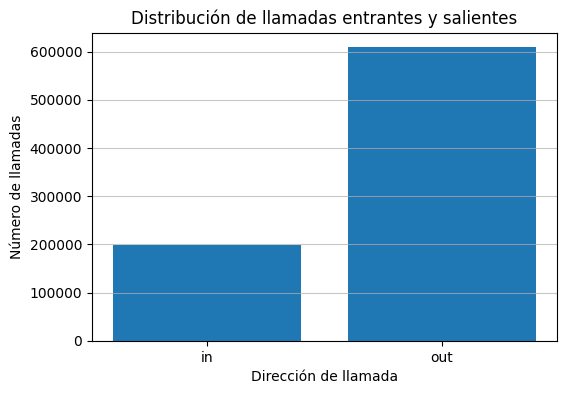

In [23]:
# Visualización de la distribución de llamadas entrantes y salientes
plt.figure(figsize=(6, 4))

plt.bar(
    calls_direction['direction'],
    calls_direction['calls_count']
)

plt.title('Distribución de llamadas entrantes y salientes')
plt.xlabel('Dirección de llamada')
plt.ylabel('Número de llamadas')
plt.grid(axis='y', alpha=0.7)
plt.show()

In [24]:
# Distribución del volumen de llamadas por cliente (user_id)
calls_by_client = (
    all_data
    .groupby('user_id')['calls_count']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

calls_by_client.describe()

,user_id,calls_count
count,307.000000,307.000000
mean,167456.817590,2627.716612
std,612.584794,11463.942823
min,166377.000000,1.000000
25%,166972.000000,43.000000
50%,167455.000000,211.000000
75%,167996.500000,1316.500000
max,168606.000000,144500.000000


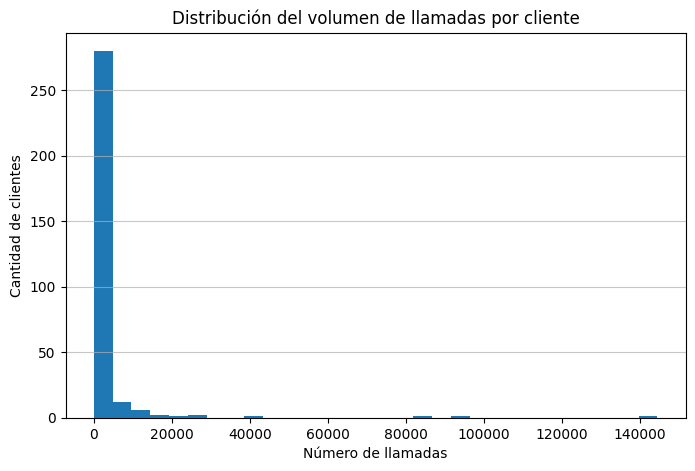

In [25]:
# histograma de distribución del volumen de llamadas por cliente
plt.figure(figsize=(8, 5))

plt.hist(calls_by_client['calls_count'], bins=30)

plt.title('Distribución del volumen de llamadas por cliente')
plt.xlabel('Número de llamadas')
plt.ylabel('Cantidad de clientes')
plt.grid(axis='y', alpha=0.7)

plt.show()

In [26]:
# Identificar los clientes con el mayor volumen de llamadas
calls_by_client.head(10)

,user_id,calls_count
0,166582,144500
1,167626,93406
2,168361,82708
3,167827,40673
4,168252,26504
5,168062,25357
6,168187,21398
7,166405,17536
8,167125,15286
9,167285,14349


<div style="border-left: 10px solid #616161;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

### Conclusiones Parte 1.1 Análisis general de llamadas

- La distribución muestra que las llamadas salientes representan la mayor proporción del tráfico telefónico registrado en la plataforma. <br>
Esto indica que el sistema se utiliza principalmente para realizar llamadas, proporcionando un contexto general sobre la operación del servicio antes de analizar el desempeño individual de los operadores.

- El análisis del volumen de llamadas por cliente muestra que la carga operativa de la plataforma no se distribuye de manera uniforme entre las organizaciones. La mayoría de los clientes registra un volumen relativamente bajo de llamadas, mientras que un reducido grupo concentra una cantidad considerablemente mayor de actividad telefónica. Esta diferencia en la carga operativa será un aspecto importante a considerar durante la evaluación del desempeño de los operadores, ya que algunos podrían gestionar un volumen de llamadas significativamente superior al de otros.

</div>


### 1.2 Duración y tiempo de espera
- Análisis de la distribución de la duración de las llamadas mediante histogramas, estadísticas descriptivas e identificación de valores atípicos.
- Análisis de la distribución del tiempo de espera "waiting_time" mediante histogramas, estadísticas descriptivas e identificación de valores atípicos.
- Comparación de los tiempos de espera entre llamadas atendidas y llamadas perdidas.


In [27]:
# Análisis de la distribución de la duración de las llamadas mediante histogramas, estadísticas descriptivas e identificación de valores atípicos.

print(all_data['avg_call_duration'].describe())

count    49002.000000
mean        66.542589
std        125.228714
min          0.000000
25%          0.000000
50%         23.666667
75%         90.000000
max       3550.000000
Name: avg_call_duration, dtype: float64


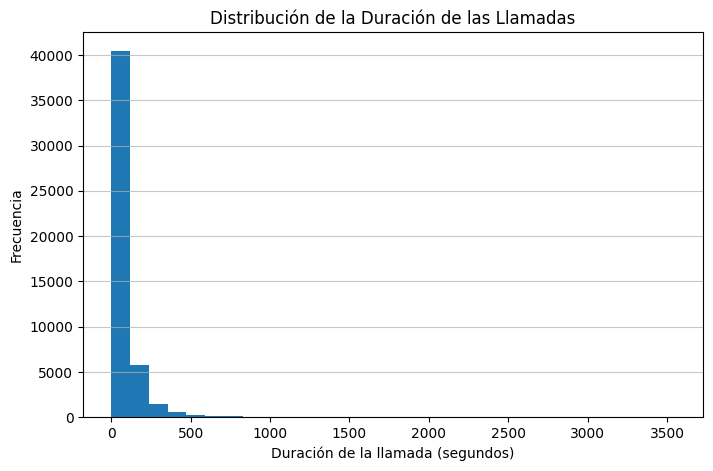

In [28]:
# Histograma de la duración de las llamadas
plt.figure(figsize=(8, 5))

plt.hist(all_data['avg_call_duration'], bins=30)
plt.title('Distribución de la Duración de las Llamadas')
plt.xlabel('Duración de la llamada (segundos)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.7)
plt.show()

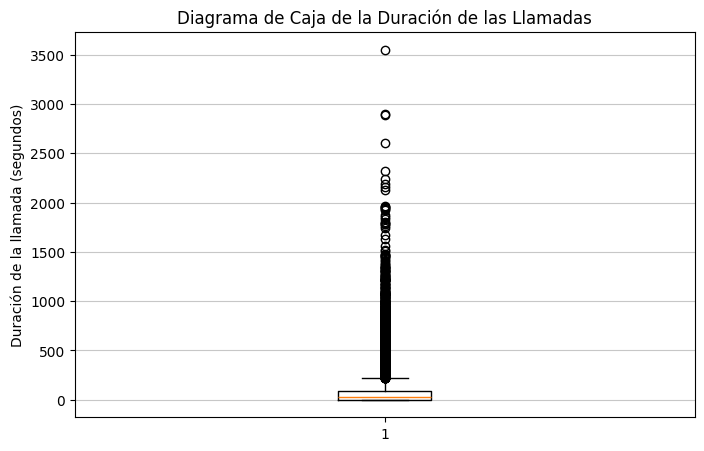

In [29]:
# diagrama de caja (boxplot) para identificar valores atípicos en la duración de las llamadas
plt.figure(figsize=(8, 5))

plt.boxplot(all_data['avg_call_duration'])
plt.title('Diagrama de Caja de la Duración de las Llamadas')
plt.ylabel('Duración de la llamada (segundos)')
plt.grid(axis='y', alpha=0.7)
plt.show()

In [30]:
# Análisis de la distribución del tiempo de espera "waiting_time" mediante histogramas, estadísticas descriptivas e identificación de valores atípicos.

print(all_data['avg_waiting_time'].describe())

count    49002.000000
mean        16.828400
std         13.878241
min          0.000000
25%          8.000000
50%         14.500000
75%         22.250000
max        465.000000
Name: avg_waiting_time, dtype: float64


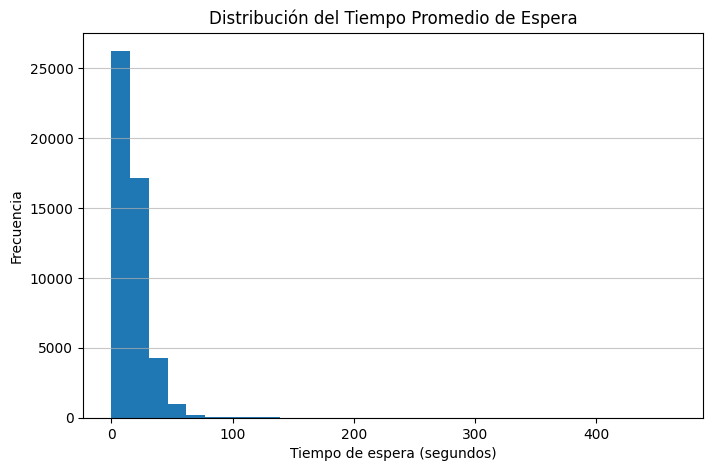

In [31]:
# Histograma de la duración del tiempo de espera "waiting_time"
plt.figure(figsize=(8, 5))

plt.hist(all_data['avg_waiting_time'], bins=30)
plt.title('Distribución del Tiempo Promedio de Espera')
plt.xlabel('Tiempo de espera (segundos)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.7)

plt.show()

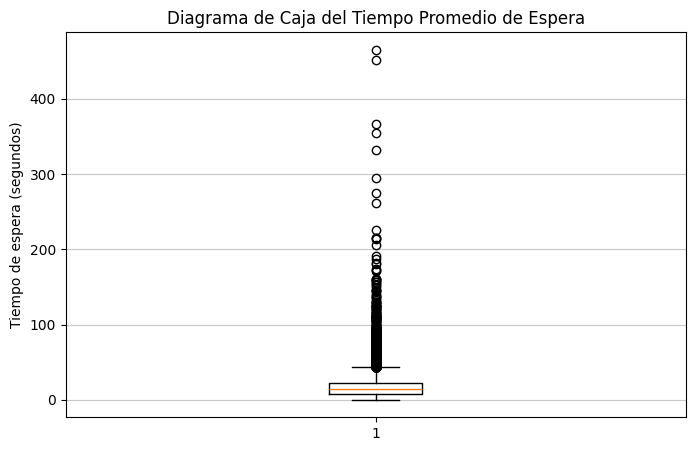

In [32]:
# diagrama de caja (boxplot) para identificar valores atípicos en la duración del tiempo de espera "waiting_time"
plt.figure(figsize=(8, 5))

plt.boxplot(all_data['avg_waiting_time'])
plt.title('Diagrama de Caja del Tiempo Promedio de Espera')
plt.ylabel('Tiempo de espera (segundos)')
plt.grid(axis='y', alpha=0.7)

plt.show()

In [33]:
# Comparación de los tiempos de espera entre llamadas atendidas y llamadas perdidas.
waiting_by_status = all_data.groupby('is_missed_call')[
    'avg_waiting_time'].describe()

print(waiting_by_status)

# Promedio y mediana del tiempo de espera según el estado de la llamada
all_data.groupby('is_missed_call')['avg_waiting_time'].agg(['mean', 'median'])

                  count       mean        std  ...   50%        75%         max
is_missed_call                                 ...                             
False           27549.0  14.500221  10.405429  ...  13.0  18.076602  451.203883
True            21453.0  19.818144  16.882297  ...  18.5  28.238095  465.000000

[2 rows x 8 columns]


,mean,median
is_missed_call,,
False,14.500221,13.0
True,19.818144,18.5


<Figure size 800x500 with 0 Axes>

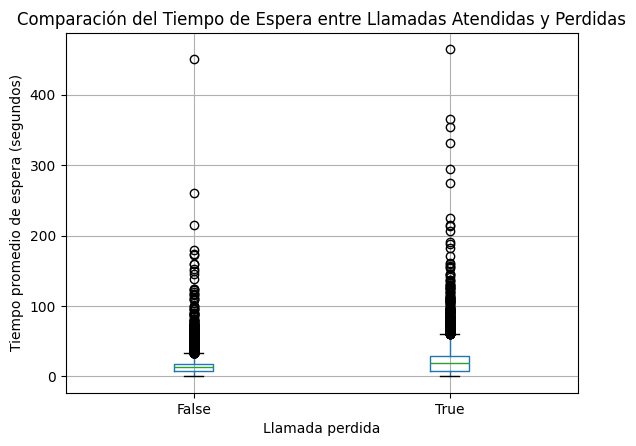

In [34]:
# Diagrama de caja para comparar el tiempo promedio de espera entre llamadas atendidas y perdidas

plt.figure(figsize=(8, 5))

all_data.boxplot(
    column='avg_waiting_time',
    by='is_missed_call'
)

plt.title('Comparación del Tiempo de Espera entre Llamadas Atendidas y Perdidas')
plt.xlabel('Llamada perdida')
plt.ylabel('Tiempo promedio de espera (segundos)')

plt.suptitle('')

plt.show()

<div style="border-left: 10px solid #616161;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

### Conclusiones Parte 1.2 Duración y tiempo de espera

- La duración promedio de las llamadas presenta una distribución asimétrica hacia la derecha. La mayoría de las llamadas tienen una duración relativamente corta, con una mediana aproximada de 24 segundos y el 75% de los registros por debajo de 90 segundos.

- La media es superior a la mediana debido a la presencia de llamadas con duraciones considerablemente más largas, lo cual indica la existencia de valores atípicos dentro de la distribución.

- Los valores extremos identificados no necesariamente representan errores en los datos, ya que pueden corresponder a interacciones más extensas entre operadores y usuarios. Por este motivo, se conservarán para los análisis posteriores.

- El análisis del tiempo promedio de espera muestra que la mayoría de las llamadas presentan tiempos de espera reducidos antes de ser atendidas. La mediana de 14.5 segundos indica que la mitad de las llamadas esperan menos de este tiempo, mientras que el 75% de los registros se mantiene por debajo de aproximadamente 22 segundos.

- La distribución presenta una asimetría positiva, donde una pequeña cantidad de llamadas registran tiempos de espera considerablemente superiores al comportamiento habitual, alcanzando valores máximos cercanos a 465 segundos. Estos valores atípicos podrían representar situaciones específicas de alta demanda, baja disponibilidad de operadores o posibles ineficiencias operativas que requieren un análisis más detallado.

- El análisis comparativo del tiempo promedio de espera muestra que las llamadas perdidas presentan tiempos de espera superiores en comparación con las llamadas atendidas. Las llamadas completadas registran una mediana aproximada de 13 segundos, mientras que las llamadas perdidas alcanzan una mediana cercana a 18.5 segundos.

- Aunque ambos grupos presentan valores atípicos con tiempos de espera elevados, se observa una mayor concentración de tiempos altos en las llamadas perdidas. Esto sugiere que un incremento en el tiempo de espera podría estar relacionado con una mayor probabilidad de que una llamada no sea atendida, por lo que esta variable puede ser relevante para evaluar el desempeño operativo de los operadores.

</div>


### 1.3 Análisis temporal

* Análisis de la evolución del volumen de llamadas registradas a lo largo del tiempo.
* Evaluación de patrones de actividad operativa según el día de la semana.

In [35]:
# Análisis de la evolución del volumen de llamadas registradas a lo largo del tiempo.
calls_by_day = (
    all_data
    .groupby(all_data['date'].dt.date)['calls_count']
    .sum()
    .reset_index()
)
calls_by_day

,date,calls_count
0,2019-08-02,21
1,2019-08-03,29
2,2019-08-04,6
3,2019-08-05,192
4,2019-08-06,229
...,...,...
114,2019-11-24,4099
115,2019-11-25,17502
116,2019-11-26,16542
117,2019-11-27,14790


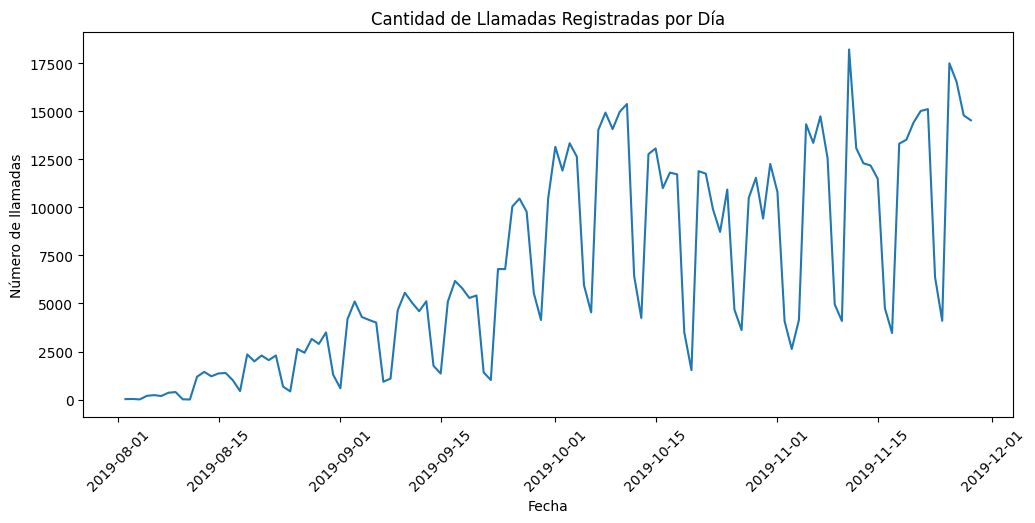

In [36]:
# Evolución del volumen de llamadas registradas por día

plt.figure(figsize=(12, 5))

plt.plot(
    calls_by_day['date'],
    calls_by_day['calls_count']
)

plt.title('Cantidad de Llamadas Registradas por Día')
plt.xlabel('Fecha')
plt.ylabel('Número de llamadas')

plt.xticks(rotation=45)

plt.show()

In [37]:
# Evaluación de patrones de actividad operativa según el día de la semana.
calls_by_day['weekday'] = pd.to_datetime(calls_by_day['date']).dt.day_name()

calls_by_weekday = (
    calls_by_day
    .groupby('weekday')['calls_count']
    .mean()
    .sort_values(ascending=False)
)

print(calls_by_weekday)

weekday
Tuesday      8921.352941
Thursday     8750.411765
Wednesday    8424.588235
Monday       8230.470588
Friday       7797.000000
Saturday     3138.176471
Sunday       2191.470588
Name: calls_count, dtype: float64


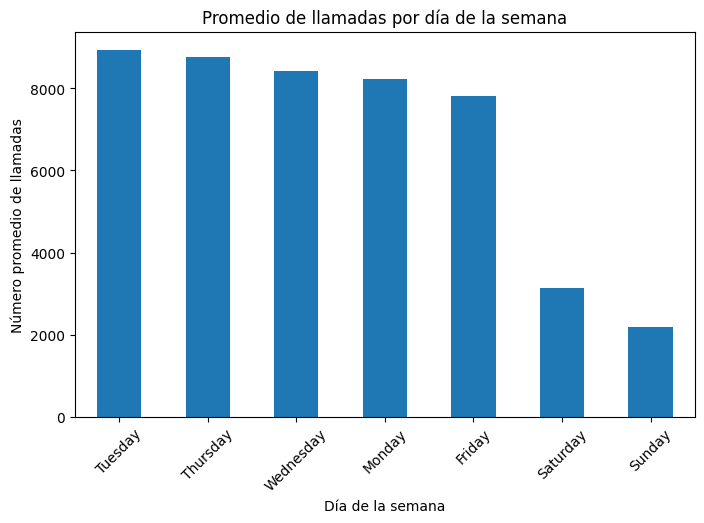

In [38]:
# Visualización del volumen promedio de llamadas por día de la semana
plt.figure(figsize=(8, 5))

calls_by_weekday.plot(kind='bar')

plt.title('Promedio de llamadas por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Número promedio de llamadas')

plt.xticks(rotation=45)

plt.show()

<div style="border-left: 10px solid #616161;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

### Conclusiones Parte 1.3 Análisis temporal
- El análisis temporal muestra un incremento progresivo en el volumen de llamadas registradas dentro de la plataforma durante el periodo analizado, indicando un aumento en la actividad operativa conforme avanza el tiempo.

- También se identificó un patrón semanal en la distribución de llamadas. Los días laborales concentran la mayor actividad, con un promedio superior a las 7,000 llamadas diarias de lunes a viernes, destacando martes y jueves como los días con mayor volumen.

- Por el contrario, los fines de semana presentan una disminución considerable en la actividad, especialmente los domingos, donde el promedio disminuye hasta aproximadamente 2,200 llamadas diarias. Esto indica que la demanda operativa de la plataforma está fuertemente asociada con los días hábiles.

</div>


<div style="border-left: 10px solid #2196F3;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

### Conclusiones de Parte 1 del Análisis Exploratorio de Datos

- El análisis exploratorio permitió comprender el comportamiento general de la actividad telefónica registrada en la plataforma e identificar características relevantes para la evaluación posterior del desempeño de los operadores. Se observó que las llamadas salientes representan la mayor parte de la actividad y que la carga operativa se distribuye de manera desigual entre los clientes, por lo que será necesario considerar estas diferencias al comparar el desempeño de los operadores.

- Asimismo, el análisis de la duración de las llamadas y del tiempo de espera mostró distribuciones asimétricas con presencia de valores atípicos que, lejos de representar errores en los datos, podrían reflejar situaciones reales de operación. En particular, se identificó que las llamadas perdidas presentan tiempos de espera superiores a las llamadas atendidas, lo que sugiere que esta variable puede constituir un indicador relevante para detectar posibles ineficiencias operativas.

- Finalmente, el análisis temporal evidenció un incremento gradual en el volumen de llamadas durante el periodo analizado, así como un patrón semanal donde la mayor actividad se concentra en los días hábiles y disminuye significativamente durante los fines de semana. En conjunto, estos hallazgos proporcionan el contexto necesario para establecer criterios objetivos que permitan identificar a los operadores con un desempeño potencialmente ineficiente en la siguiente etapa del análisis.

</div>


## 2. Identificación de operadores ineficaces

El objetivo de esta sección es definir métricas de desempeño que permitan identificar operadores ineficaces dentro de la plataforma. Para ello, se evaluarán indicadores relacionados con llamadas perdidas, tiempos de espera y actividad saliente con el fin de detectar patrones de bajo desempeño operativo y clasificar operadores según su nivel de eficiencia.

### 2.1 Definición de métricas y criterios

* Análisis de la tasa de llamadas perdidas por operador.
* Análisis del tiempo de espera promedio por operador.
* Análisis de la actividad de llamadas salientes por operador.

In [39]:
# Cálculo de tasas de llamadas perdidas por operador.
# Filtrar llamadas entrantes con operador asignado.
incoming_calls = all_data[
    (all_data["direction"] == "in") &
    (all_data["operator_id"].notna())
].copy()

# Agrupar por operador.
incoming_by_operator = (
    incoming_calls
    .groupby("operator_id")
    .agg(
        total_incoming_calls=("calls_count", "sum"),
        missed_calls=(
            "calls_count",
            lambda x: x[incoming_calls.loc[x.index, "is_missed_call"]].sum()
        )
    )
)

# Calcular la tasa de llamadas perdidas por operador.
incoming_by_operator["missed_call_rate"] = (
    incoming_by_operator["missed_calls"] /
    incoming_by_operator["total_incoming_calls"]
)
incoming_by_operator["missed_call_rate"] *= 100

incoming_by_operator.head()

,total_incoming_calls,missed_calls,missed_call_rate
operator_id,,,
879896.0,58,0,0.0
879898.0,104,0,0.0
880020.0,7,0,0.0
880022.0,8,0,0.0
880026.0,24,0,0.0


In [40]:
incoming_by_operator.describe()

,total_incoming_calls,missed_calls,missed_call_rate
count,754.000000,754.000000,754.000000
mean,124.405836,1.228117,1.757385
std,356.450649,3.797106,6.532449
min,1.000000,0.000000,0.000000
25%,4.000000,0.000000,0.000000
50%,17.000000,0.000000,0.000000
75%,78.750000,1.000000,0.674678
max,4766.000000,52.000000,100.000000


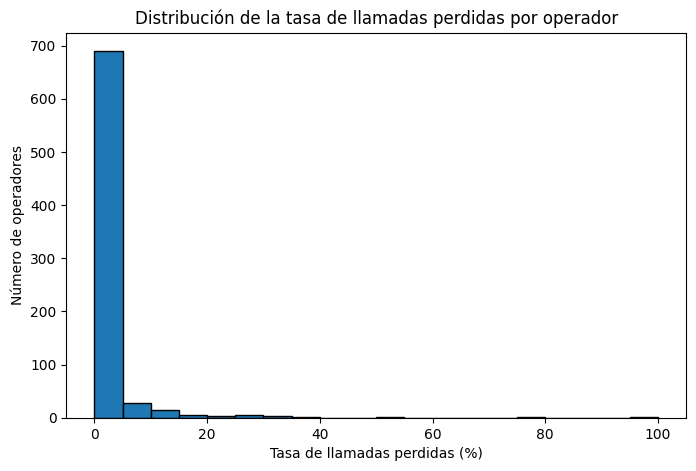

In [41]:
plt.figure(figsize=(8, 5))

plt.hist(
    incoming_by_operator["missed_call_rate"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribución de la tasa de llamadas perdidas por operador")
plt.xlabel("Tasa de llamadas perdidas (%)")
plt.ylabel("Número de operadores")

plt.show()

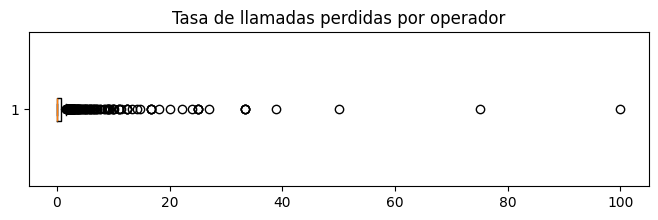

In [42]:
plt.figure(figsize=(8, 2))

plt.boxplot(
    incoming_by_operator["missed_call_rate"],
    vert=False
)

plt.title("Tasa de llamadas perdidas por operador")

plt.show()

In [43]:
# revisar datos de los primeros operadores
incoming_by_operator.sort_values(
    by="missed_call_rate",
    ascending=False
).head(15)

,total_incoming_calls,missed_calls,missed_call_rate
operator_id,,,
948756.0,1,1,100.000000
904344.0,4,3,75.000000
913886.0,2,1,50.000000
906392.0,18,7,38.888889
937432.0,3,1,33.333333
957922.0,3,1,33.333333
897872.0,3,1,33.333333
934098.0,6,2,33.333333
906412.0,26,7,26.923077


In [44]:
# Análisis del tiempo promedio de espera por operador.

waiting_time_by_operator = (
    incoming_calls
    .groupby("operator_id")
    .agg(
        total_waiting_time=("waiting_time", "sum"),
        total_incoming_calls=("calls_count", "sum")
    )
)

waiting_time_by_operator["avg_waiting_time"] = (
    waiting_time_by_operator["total_waiting_time"] /
    waiting_time_by_operator["total_incoming_calls"]
)
waiting_time_by_operator.head()

,total_waiting_time,total_incoming_calls,avg_waiting_time
operator_id,,,
879896.0,574,58,9.896552
879898.0,1680,104,16.153846
880020.0,54,7,7.714286
880022.0,112,8,14.000000
880026.0,143,24,5.958333


In [45]:
waiting_time_by_operator.describe()

,total_waiting_time,total_incoming_calls,avg_waiting_time
count,754.000000,754.000000,754.000000
mean,1635.656499,124.405836,17.491612
std,4637.607919,356.450649,12.171988
min,1.000000,1.000000,0.683673
25%,62.000000,4.000000,9.398782
50%,255.000000,17.000000,14.430502
75%,1064.250000,78.750000,21.838889
max,52875.000000,4766.000000,115.500000


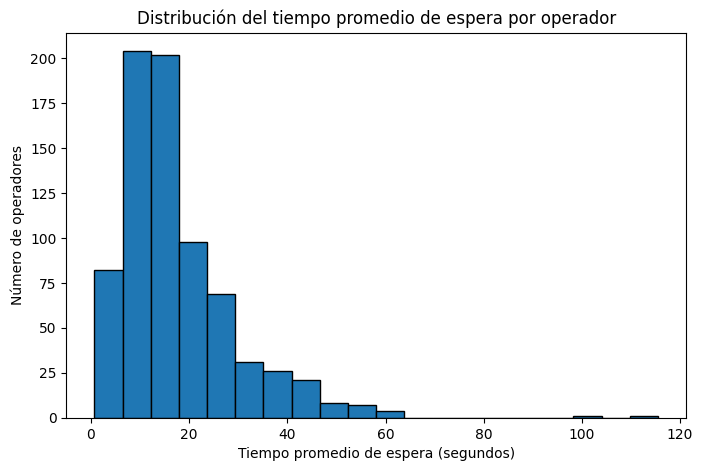

In [46]:
plt.figure(figsize=(8, 5))

plt.hist(
    waiting_time_by_operator["avg_waiting_time"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribución del tiempo promedio de espera por operador")
plt.xlabel("Tiempo promedio de espera (segundos)")
plt.ylabel("Número de operadores")

plt.show()

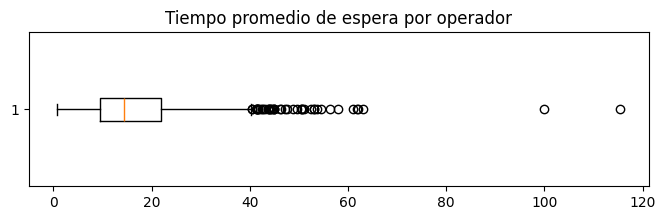

In [47]:
plt.figure(figsize=(8, 2))

plt.boxplot(
    waiting_time_by_operator["avg_waiting_time"],
    vert=False
)

plt.title("Tiempo promedio de espera por operador")

plt.show()

In [48]:
# Análisis de la actividad de llamadas salientes por operador.
# definir metrica para llamadas salientes por operador
outgoing_calls = all_data[
    (all_data["direction"] == "out") &
    (all_data["operator_id"].notna())
].copy()

# Agrupar por operador y calcular el total de llamadas salientes
outgoing_activity_by_operator = (
    outgoing_calls
    .groupby("operator_id")
    .agg(
        total_outgoing_calls=("calls_count", "sum")
    )
    .sort_values(by="total_outgoing_calls", ascending=False)
)

print(outgoing_activity_by_operator.head())
outgoing_activity_by_operator.describe()

             total_outgoing_calls
operator_id                      
885890.0                    58977
885876.0                    58437
929428.0                    23754
925922.0                    19603
908640.0                    14239


,total_outgoing_calls
count,882.000000
mean,689.731293
std,3122.953946
min,1.000000
25%,11.000000
50%,90.000000
75%,597.250000
max,58977.000000


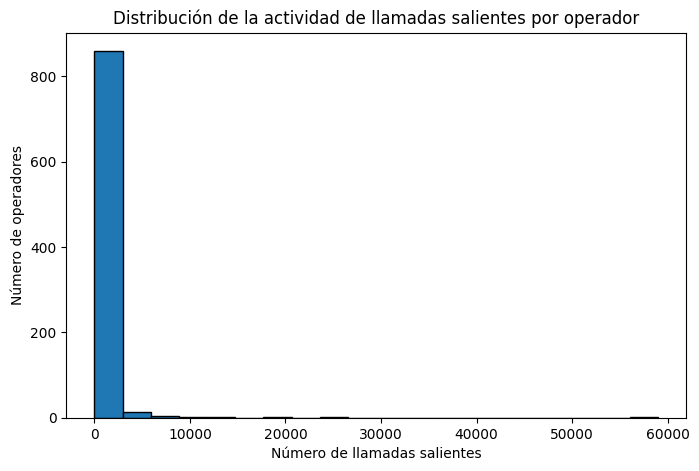

In [49]:
plt.figure(figsize=(8, 5))

plt.hist(
    outgoing_activity_by_operator["total_outgoing_calls"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribución de la actividad de llamadas salientes por operador")
plt.xlabel("Número de llamadas salientes")
plt.ylabel("Número de operadores")

plt.show()

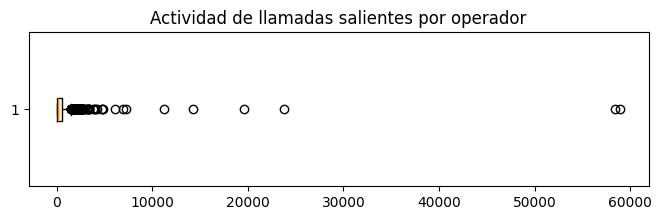

In [50]:
plt.figure(figsize=(8, 2))

plt.boxplot(
    outgoing_activity_by_operator["total_outgoing_calls"],
    vert=False
)

plt.title("Actividad de llamadas salientes por operador")

plt.show()

<div style="border-left: 10px solid #616161;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

### Conclusiones de la Parte 2.1 Definición de métricas y criterios
- El análisis de las métricas de desempeño permitió identificar diferencias importantes en la operación de los operadores y establecer una base objetiva para su evaluación. 
En las tres métricas analizadas se observó una distribución marcadamente asimétrica hacia la derecha y la presencia de valores atípicos, por lo que la mediana y los cuartiles resultan medidas más representativas que la media para describir el comportamiento típico de los operadores.

- La **tasa de llamadas perdidas** presentó una media de **1.76%**, una mediana de **0%** y un tercer cuartil de apenas **0.67%**, lo que indica que la mayoría de los operadores perdió pocas o ninguna llamada durante el periodo analizado. 
No obstante, se identificaron valores extremos de hasta **100%**, asociados en algunos casos a operadores con un volumen muy reducido de llamadas entrantes; por ejemplo, un operador registró una tasa del **100%** al haber recibido únicamente **una llamada**, la cual no fue atendida. Esto evidencia que esta métrica debe interpretarse considerando también el volumen de llamadas gestionadas.

- Respecto al **tiempo promedio de espera**, la media fue de aproximadamente **17.5 segundos**, mientras que la mediana se ubicó en **14.4 segundos** y el 75% de los operadores registró tiempos inferiores a **21.8 segundos**. 
Sin embargo, se observaron operadores con tiempos promedio de espera de hasta **115.5 segundos**, reflejando diferencias importantes en la capacidad de respuesta y la presencia de valores atípicos que incrementan el promedio general.

- Por su parte, la **actividad de llamadas salientes** presentó la mayor dispersión entre las métricas analizadas. De los **882 operadores** con actividad saliente registrada, la mediana fue de **90 llamadas**, mientras que el 75% realizó menos de **598 llamadas** durante el periodo analizado. 
En contraste, algunos operadores concentraron un volumen excepcionalmente alto, alcanzando hasta **58,977 llamadas salientes**, lo que evidencia que la carga de trabajo relacionada con este tipo de llamadas no se distribuye de manera uniforme. 
Asimismo, la diferencia entre el número de operadores con llamadas entrantes (**754**) y aquellos con actividad saliente (**882**) sugiere que no todos desempeñan las mismas funciones dentro de la plataforma, por lo que esta métrica deberá interpretarse considerando el rol operativo de cada operador.


- En conjunto, estas tres métricas ofrecen una visión complementaria del desempeño operativo de los operadores y proporcionan una base sólida para establecer los criterios de clasificación e identificar operadores potencialmente ineficaces en la siguiente etapa del análisis.

</div>


### 2.2 Clasificación y análisis de operadores

* Definición de los criterios de clasificación.
* Análisis de operadores con mayores tasas de llamadas perdidas.
* Evaluación de operadores con mayores tiempos de espera.
* Identificación de operadores con baja actividad saliente.
* Comparación del desempeño de operadores respecto a los criterios establecidos.
* Análisis de patrones comunes entre operadores potencialmente ineficaces.
* Interpretación de posibles causas asociadas al bajo desempeño operativo.

---

#### *Definición de los criterios de clasificación.*

Una vez analizadas las métricas de desempeño de los operadores, es necesario establecer criterios objetivos que permitan identificar aquellos con un comportamiento potencialmente Deficiente. Dado que las distribuciones de las tres métricas presentan asimetría y valores atípicos, los criterios de clasificación se definirán utilizando percentiles, evitando establecer umbrales arbitrarios.

Para este análisis se considerarán tres criterios independientes:

- **Criterio 1:** Se evaluará la **tasa de llamadas perdidas** utilizando como umbral el **percentil 75**. Los operadores con una tasa superior a este valor serán considerados con un desempeño desfavorable respecto a este indicador.

- **Criterio 2:** Se evaluará el **tiempo promedio de espera** utilizando como umbral el **percentil 75**. Los operadores con tiempos superiores a este valor serán considerados con un desempeño desfavorable respecto a este indicador.

- **Criterio 3:** Se evaluará la **actividad de llamadas salientes** utilizando como umbral el **percentil 25**. Debido a que no todos los operadores realizan llamadas salientes, este criterio únicamente se aplicará a aquellos que registran actividad saliente durante el periodo analizado. Los operadores con un volumen inferior a este umbral serán considerados con una baja actividad saliente.

Los criterios establecidos servirán como referencia para evaluar el desempeño individual de los operadores en los apartados siguientes. Posteriormente, los resultados de las tres métricas se analizarán de manera conjunta para identificar operadores potencialmente ineficaces.

In [51]:
# Definir clases de operadores según su actividad
operator_activity = (
    all_data
    .groupby("operator_id")
    .agg(
        incoming_calls=(
            "direction",
            lambda x: (x == "in").sum()
        ),
        outgoing_calls=(
            "direction",
            lambda x: (x == "out").sum()
        )
    )
)

operator_activity.head()

# Clasificación de operadores según su actividad
operator_activity["tipo_operador"] = "Mixto"

operator_activity.loc[
    (operator_activity["incoming_calls"] > 0) &
    (operator_activity["outgoing_calls"] == 0),
    "tipo_operador"
] = "Solo entrantes"

operator_activity.loc[
    (operator_activity["incoming_calls"] == 0) &
    (operator_activity["outgoing_calls"] > 0),
    "tipo_operador"
] = "Solo salientes"

operator_activity["tipo_operador"].value_counts()

tipo_operador
Mixto             544
Solo salientes    338
Solo entrantes    210
Name: count, dtype: int64

In [52]:
operator_activity.head()

,incoming_calls,outgoing_calls,tipo_operador
operator_id,,,
879896.0,21,96,Mixto
879898.0,57,170,Mixto
880020.0,7,13,Mixto
880022.0,8,62,Mixto
880026.0,18,164,Mixto


In [53]:
# Calculo de percentiles
missed_call_threshold = incoming_by_operator["missed_call_rate"].quantile(0.75)
waiting_time_threshold = waiting_time_by_operator["avg_waiting_time"].quantile(
    0.75)
outgoing_calls_threshold = outgoing_activity_by_operator["total_outgoing_calls"].quantile(
    0.25)

# Organizar todo en una tabla DataFrame
criterio = pd.DataFrame({
    "Métrica": [
        "Tasa de llamadas perdidas",
        "Tiempo promedio de espera",
        "Actividad de llamadas salientes"
    ],
    "Percentil": [
        "P75",
        "P75",
        "P25"
    ],
    "Umbral": [
        missed_call_threshold,
        waiting_time_threshold,
        outgoing_calls_threshold
    ]
})

criterio

,Métrica,Percentil,Umbral
0,Tasa de llamadas perdidas,P75,0.674678
1,Tiempo promedio de espera,P75,21.838889
2,Actividad de llamadas salientes,P25,11.000000


---
#### Análisis de operadores con mayores tasas de llamadas perdidas.

Con base en los criterios definidos previamente, se identifican los operadores cuya tasa de llamadas perdidas supera el percentil 75 de la distribución (**0.67%**). Estos operadores representan aquellos cuyo desempeño, en términos de llamadas no atendidas, es menos favorable que el observado en la mayoría de los operadores durante el periodo analizado.

Es importante considerar que una tasa elevada de llamadas perdidas debe interpretarse junto con el volumen de llamadas gestionadas, ya que porcentajes altos pueden originarse por un número reducido de llamadas entrantes y no necesariamente reflejan un desempeño operativo deficiente.

In [54]:
# Filtrar operadores que superan el umbral de la tasa de llamadas perdidas
high_missed_rate = incoming_by_operator[
    incoming_by_operator["missed_call_rate"] > missed_call_threshold
].sort_values(
    by="missed_call_rate",
    ascending=False
)

high_missed_rate.head(15)

,total_incoming_calls,missed_calls,missed_call_rate
operator_id,,,
948756.0,1,1,100.000000
904344.0,4,3,75.000000
913886.0,2,1,50.000000
906392.0,18,7,38.888889
897872.0,3,1,33.333333
934098.0,6,2,33.333333
937432.0,3,1,33.333333
957922.0,3,1,33.333333
906412.0,26,7,26.923077


In [55]:
print(
    f"Operadores que superan el criterio 'high_missed_rate': "
    f"{len(high_missed_rate)} de {len(incoming_by_operator)}"
)

Operadores que superan el criterio 'high_missed_rate': 189 de 754


---
#### Evaluación de operadores con mayores tiempos de espera.

Con base en los criterios establecidos previamente, se identifican los operadores cuyo tiempo promedio de espera supera el percentil 75 de la distribución (**21.84 segundos**). Estos operadores presentan tiempos de espera superiores al comportamiento habitual observado durante el periodo analizado y, por tanto, representan casos que requieren una evaluación más detallada.

Al igual que con la tasa de llamadas perdidas, el tiempo promedio de espera debe interpretarse considerando el volumen de llamadas atendidas, ya que valores elevados pueden originarse por un número reducido de llamadas gestionadas.

In [56]:
# Filtrar operadores que superan el umbral del tiempo promedio de espera.

high_waiting_time = waiting_time_by_operator[
    waiting_time_by_operator["avg_waiting_time"] > waiting_time_threshold
].sort_values(
    by="avg_waiting_time",
    ascending=False
)

high_waiting_time.head()
high_waiting_time.shape

(189, 3)

---
#### Identificación de operadores con baja actividad saliente.

La actividad de llamadas salientes únicamente se evalúa para aquellos operadores cuya función contempla la realización de llamadas salientes (operadores mixtos y operadores de solo salientes). Para ello, se identifican los operadores cuyo volumen de llamadas salientes se encuentra por debajo del percentil 25 de la distribución (**11 llamadas**), ya que representan los casos con menor actividad saliente durante el periodo analizado.

Este criterio no se aplica a los operadores que únicamente gestionan llamadas entrantes, debido a que la ausencia de llamadas salientes forma parte de sus funciones operativas y no constituye un indicador de bajo desempeño.

In [57]:
# Operadores que realizan llamadas salientes.

operators_with_outgoing = operator_activity[
    operator_activity["tipo_operador"] != "Solo entrantes"
]
operators_with_outgoing["tipo_operador"].value_counts()

tipo_operador
Mixto             544
Solo salientes    338
Name: count, dtype: int64

In [58]:
# Filtrar Operadores con Baja Actividad Saliente
low_outgoing_activity = outgoing_activity_by_operator[
    outgoing_activity_by_operator["total_outgoing_calls"] < outgoing_calls_threshold
].sort_values(
    by="total_outgoing_calls"
)

print(
    f"Operadores que cumplen el criterio 'total_outgoing_calls': "
    f"{len(low_outgoing_activity)} de {len(outgoing_activity_by_operator)}"
)

Operadores que cumplen el criterio 'total_outgoing_calls': 214 de 882


---
#### Comparación del desempeño de operadores respecto a los criterios establecidos.

In [59]:
# Organizar todo en una tabla DataFrame
operator_metrics = (
    incoming_by_operator[
        ["total_incoming_calls", "missed_calls", "missed_call_rate"]
    ]
    .merge(
        waiting_time_by_operator[["avg_waiting_time"]],
        left_index=True,
        right_index=True,
        how="outer"
    )
    .merge(
        outgoing_activity_by_operator[["total_outgoing_calls"]],
        left_index=True,
        right_index=True,
        how="outer"
    )
)

operator_metrics = operator_metrics.merge(
    operator_activity[["tipo_operador"]],
    left_index=True,
    right_index=True,
    how="left"
)

operator_metrics.head()

,total_incoming_calls,missed_calls,missed_call_rate,avg_waiting_time,total_outgoing_calls,tipo_operador
operator_id,,,,,,
879896.0,58.0,0.0,0.0,9.896552,872.0,Mixto
879898.0,104.0,0.0,0.0,16.153846,7209.0,Mixto
880020.0,7.0,0.0,0.0,7.714286,38.0,Mixto
880022.0,8.0,0.0,0.0,14.000000,189.0,Mixto
880026.0,24.0,0.0,0.0,5.958333,2208.0,Mixto


In [60]:
# Comprobación de cantidad de operadores después de los merge
operator_metrics.shape[0]

1092

In [61]:
# Definir métricas de desempeño según los criterios establecidos
operator_metrics["high_missed_calls"] = (
    operator_metrics["missed_call_rate"] >
    missed_call_threshold
)

operator_metrics["high_waiting_time"] = (
    operator_metrics["avg_waiting_time"] >
    waiting_time_threshold
)

operator_metrics["low_outgoing_activity"] = (
    operator_metrics["total_outgoing_calls"] <
    outgoing_calls_threshold
)

# Ajustar la métrica de baja actividad saliente para operadores que solo realizan llamadas entrantes
operator_metrics.loc[
    operator_metrics["tipo_operador"] == "Solo entrantes",
    "low_outgoing_activity"
] = False

operator_metrics.head()

,total_incoming_calls,missed_calls,missed_call_rate,avg_waiting_time,total_outgoing_calls,tipo_operador,high_missed_calls,high_waiting_time,low_outgoing_activity
operator_id,,,,,,,,,
879896.0,58.0,0.0,0.0,9.896552,872.0,Mixto,False,False,False
879898.0,104.0,0.0,0.0,16.153846,7209.0,Mixto,False,False,False
880020.0,7.0,0.0,0.0,7.714286,38.0,Mixto,False,False,False
880022.0,8.0,0.0,0.0,14.000000,189.0,Mixto,False,False,False
880026.0,24.0,0.0,0.0,5.958333,2208.0,Mixto,False,False,False


In [62]:
# Contar cuántos criterios incumple cada operador
operator_metrics["criteria_failed"] = (
    operator_metrics[
        [
            "high_missed_calls",
            "high_waiting_time",
            "low_outgoing_activity"
        ]
    ]
    .sum(axis=1)
)

operator_metrics.head()

,total_incoming_calls,missed_calls,missed_call_rate,avg_waiting_time,total_outgoing_calls,tipo_operador,high_missed_calls,high_waiting_time,low_outgoing_activity,criteria_failed
operator_id,,,,,,,,,,
879896.0,58.0,0.0,0.0,9.896552,872.0,Mixto,False,False,False,0
879898.0,104.0,0.0,0.0,16.153846,7209.0,Mixto,False,False,False,0
880020.0,7.0,0.0,0.0,7.714286,38.0,Mixto,False,False,False,0
880022.0,8.0,0.0,0.0,14.000000,189.0,Mixto,False,False,False,0
880026.0,24.0,0.0,0.0,5.958333,2208.0,Mixto,False,False,False,0


<div style="border-left: 10px solid #616161;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

#### Lógica de clasificación de operadores

Debido a que no todos los operadores desempeñan las mismas funciones, la clasificación se realizó considerando únicamente los criterios aplicables a cada tipo de operador.

- Los operadores mixtos fueron evaluados mediante los tres criterios definidos: tasa de llamadas perdidas, tiempo promedio de espera y actividad de llamadas salientes.
- Los operadores de solo entrantes fueron evaluados mediante la tasa de llamadas perdidas y el tiempo promedio de espera.
- Los operadores de solo salientes fueron evaluados únicamente mediante la actividad de llamadas salientes.

De esta forma se evita penalizar a un operador por métricas que no corresponden a sus responsabilidades operativas.

Con base en el número de criterios incumplidos, se establecieron distintos niveles de desempeño para cada tipo de operador. Un mayor número de criterios incumplidos representa un mayor grado de desviación respecto al desempeño esperado y, por lo tanto, una mayor necesidad de seguimiento o implementación de acciones de mejora.

Los niveles de desempeño definidos son los siguientes:

| Tipo de operador | Criterios incumplidos | Clasificación |
|------------------|:---------------------:|---------------|
| **Mixto** | 0 | Desempeño Esperado |
| | 1 | Desempeño Bajo |
| | 2 | Desempeño Deficiente |
| | 3 | Desempeño Crítico |
| **Solo entrantes** | 0 | Desempeño Esperado |
| | 1 | Desempeño Bajo |
| | 2 | Desempeño Deficiente |
| **Solo salientes** | 0 | Desempeño Esperado |
| | 1 | Desempeño Deficiente |

</div>


In [63]:
# Inicializar la clasificacion
operator_metrics["classification"] = "Desempeño Esperado"

operator_metrics

# Clasificar Operadores mixtos
operator_metrics.loc[
    (operator_metrics["tipo_operador"] == "Mixto") &
    (operator_metrics["criteria_failed"] == 1),
    "classification"
] = "Desempeño Bajo"

operator_metrics.loc[
    (operator_metrics["tipo_operador"] == "Mixto") &
    (operator_metrics["criteria_failed"] == 2),
    "classification"
] = "Desempeño Deficiente"

operator_metrics.loc[
    (operator_metrics["tipo_operador"] == "Mixto") &
    (operator_metrics["criteria_failed"] == 3),
    "classification"
] = "Desempeño Crítico"

# Clasificar Operadores de solo salientes
operator_metrics.loc[
    (operator_metrics["tipo_operador"] == "Solo salientes") &
    (operator_metrics["criteria_failed"] == 1),
    "classification"
] = "Desempeño Deficiente"

# Clasificar Operadores de solo entrantes
operator_metrics.loc[
    (operator_metrics["tipo_operador"] == "Solo entrantes") &
    (operator_metrics["criteria_failed"] == 1),
    "classification"
] = "Desempeño Bajo"

operator_metrics.loc[
    (operator_metrics["tipo_operador"] == "Solo entrantes") &
    (operator_metrics["criteria_failed"] == 2),
    "classification"
] = "Desempeño Deficiente"

# Verificar la clasificación de los operadores
classification_summary = (
    operator_metrics
    .groupby("tipo_operador")["classification"]
    .value_counts()
    .unstack(fill_value=0)
)
classification_summary

classification,Desempeño Bajo,Desempeño Crítico,Desempeño Deficiente,Desempeño Esperado
tipo_operador,,,,
Mixto,226,2,78,238
Solo entrantes,79,0,12,119
Solo salientes,0,0,101,237


In [64]:
# Calcular porcentaje de Operadores con bajo desempeño
ineffective_operators = operator_metrics[operator_metrics["classification"]
                                         != "Desempeño Esperado"]
# Calcular porcentaje de operadores con desempeño inferior al esperado
performance_rate = pd.DataFrame({
    "Operadores": [
        len(ineffective_operators),
        len(operator_metrics) - len(ineffective_operators)
    ]
},
    index=[
    "Desempeño inferior al esperado",
    "Desempeño esperado"
])

performance_rate["Porcentaje (%)"] = (
    performance_rate["Operadores"]
    / performance_rate["Operadores"].sum()
    * 100
).round(2)

performance_rate

,Operadores,Porcentaje (%)
Desempeño inferior al esperado,498,45.6
Desempeño esperado,594,54.4


---
#### Análisis de patrones comunes entre operadores con desempeño inferior al esperado

In [65]:
# Filtrar operadores cuyo desempeño requiere atención
ineffective_operators = operator_metrics[
    operator_metrics["classification"] != "Desempeño Esperado"
].copy()

ineffective_operators.head()

,total_incoming_calls,missed_calls,missed_call_rate,avg_waiting_time,total_outgoing_calls,tipo_operador,high_missed_calls,high_waiting_time,low_outgoing_activity,criteria_failed,classification
operator_id,,,,,,,,,,,
882476.0,3.0,0.0,0.000000,31.666667,NaN,Solo entrantes,False,True,False,1,Desempeño Bajo
882478.0,3.0,0.0,0.000000,25.333333,1.0,Mixto,False,True,True,2,Desempeño Deficiente
882680.0,99.0,3.0,3.030303,16.070707,NaN,Solo entrantes,True,False,False,1,Desempeño Bajo
882686.0,766.0,6.0,0.783290,14.714099,2884.0,Mixto,True,False,False,1,Desempeño Bajo
882688.0,15.0,0.0,0.000000,44.866667,43.0,Mixto,False,True,False,1,Desempeño Bajo


In [66]:
# Analisis por nivel de desempeño
performance_summary = (
    ineffective_operators["classification"]
    .value_counts()
    .to_frame(name="Operadores")
)

performance_summary["Porcentaje (%)"] = (
    performance_summary["Operadores"]
    / performance_summary["Operadores"].sum()
    * 100
).round(2)

print("Porcentajes de cada clasificación de operadores con desempeño inferior al esperado")
performance_summary

Porcentajes de cada clasificación de operadores con desempeño inferior al esperado


,Operadores,Porcentaje (%)
classification,,
Desempeño Bajo,305,61.24
Desempeño Deficiente,191,38.35
Desempeño Crítico,2,0.40


¿Cuál es el patrón de incumplimiento dentro de cada tipo de operador?

In [67]:
# Calcular porcentaje de tipo de operador mixto
mixed_summary = (
    ineffective_operators[
        ineffective_operators["tipo_operador"] == "Mixto"
    ][
        [
            "high_missed_calls",
            "high_waiting_time",
            "low_outgoing_activity"
        ]
    ]
    .sum()
    .to_frame(name="Operadores")
)

mixed_summary["Porcentaje (%)"] = (
    mixed_summary["Operadores"]
    / len(
        ineffective_operators[
            ineffective_operators["tipo_operador"] == "Mixto"
        ]
    )
    * 100
).round(2)

mixed_summary

# Calcular porcentaje de tipo de operador solo salientes
outgoing_summary = (
    ineffective_operators[
        ineffective_operators["tipo_operador"] == "Solo salientes"
    ][
        ["low_outgoing_activity"]
    ]
    .sum()
    .to_frame(name="Operadores")
)

outgoing_summary["Porcentaje (%)"] = (
    outgoing_summary["Operadores"]
    / len(
        ineffective_operators[
            ineffective_operators["tipo_operador"] == "Solo salientes"
        ]
    )
    * 100
).round(2)

outgoing_summary

# Calcular porcentaje de tipo de operador solo entrantes
incoming_summary = (
    ineffective_operators[
        ineffective_operators["tipo_operador"] == "Solo entrantes"
    ][
        [
            "high_missed_calls",
            "high_waiting_time"
        ]
    ]
    .sum()
    .to_frame(name="Operadores")
)

incoming_summary["Porcentaje (%)"] = (
    incoming_summary["Operadores"]
    / len(
        ineffective_operators[
            ineffective_operators["tipo_operador"] == "Solo entrantes"
        ]
    )
    * 100
).round(2)

print("Tipo de Operador Mixto")
print(mixed_summary)
print("\n---------------------------------------------------------")
print("Tipo de operador Solo Salientes")
print(outgoing_summary)
print("\n---------------------------------------------------------")
print("Tipo de operador Solo Entrantes")
print(incoming_summary)

Tipo de Operador Mixto
                       Operadores  Porcentaje (%)
high_missed_calls             151           49.35
high_waiting_time             124           40.52
low_outgoing_activity         113           36.93

---------------------------------------------------------
Tipo de operador Solo Salientes
                       Operadores  Porcentaje (%)
low_outgoing_activity         101           100.0

---------------------------------------------------------
Tipo de operador Solo Entrantes
                   Operadores  Porcentaje (%)
high_missed_calls          38           41.76
high_waiting_time          65           71.43


<div style="border-left: 10px solid #616161;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

### Conclusiones Parte 2.2 Clasificación y análisis de operadores

- En esta sección se establecieron criterios objetivos para identificar operadores con un desempeño inferior al esperado utilizando percentiles de la distribución de las métricas analizadas. Se definieron umbrales para la tasa de llamadas perdidas (P75), el tiempo promedio de espera (P75) y la actividad de llamadas salientes (P25), evitando el uso de valores arbitrarios y adaptando cada criterio a las responsabilidades operativas de cada tipo de operador.

- Posteriormente se evaluó de manera independiente el comportamiento de cada métrica. Se identificaron los operadores con mayores tasas de llamadas perdidas, aquellos con tiempos promedio de espera superiores al comportamiento habitual y los operadores con menor actividad saliente, considerando únicamente a quienes realizan llamadas salientes como parte de sus funciones.

- Una vez evaluadas las tres métricas, se integraron en un único esquema de clasificación que contabiliza el número de criterios incumplidos por cada operador. 
La clasificación fue diseñada de forma diferenciada para operadores mixtos, operadores de solo entradas y operadores de solo salidas, garantizando que cada uno fuera evaluado únicamente con los indicadores que corresponden a sus responsabilidades operativas.

- Como resultado de este proceso, el **54.4 %** de los operadores fueron clasificados con un desempeño esperado, mientras que el **45.6 %** presentó algún nivel de desempeño inferior al esperado. Dentro de este último grupo predominó la categoría de **Bajo rendimiento (61.24 %)**, seguida por **Desempeño deficiente (38.35 %)**, mientras que únicamente **dos operadores (0.40 %)** fueron clasificados con un desempeño crítico.

- Finalmente, el análisis de patrones permitió identificar diferencias claras entre los distintos tipos de operadores. En los operadores mixtos, el incumplimiento de los criterios se distribuye de forma relativamente equilibrada entre las llamadas perdidas (49.35 %), los tiempos promedio de espera (40.52 %) y la baja actividad saliente (36.93 %), por lo que no existe un único indicador predominante.

- En los operadores de solo entradas, el criterio más frecuente corresponde al tiempo promedio de espera (71.43 %), seguido por la tasa de llamadas perdidas (41.76 %), lo que indica que el tiempo de espera es el principal factor asociado a su bajo desempeño.

- En los operadores de solo salidas, el 100 % de los casos con desempeño inferior al esperado incumple el criterio de baja actividad de llamadas salientes, al ser el único indicador aplicable a las funciones que desempeñan.

</div>


<div style="border-left: 10px solid #2196F3;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

## Conclusiones Parte 2. Identificación de operadores ineficaces

- En esta etapa se definieron tres métricas para evaluar el desempeño de los operadores: la **tasa de llamadas perdidas**, el **tiempo promedio de espera** y la **actividad de llamadas salientes**. El análisis mostró distribuciones marcadamente asimétricas y la presencia de valores atípicos en las tres métricas, por lo que se utilizaron la mediana y los percentiles como referencia para establecer criterios objetivos de evaluación.

- A partir de estos resultados se definieron umbrales basados en percentiles para identificar operadores con un desempeño inferior al esperado, considerando las diferencias entre operadores mixtos, de solo entradas y de solo salidas. Esta clasificación permitió evaluar a cada operador únicamente con las métricas relacionadas con sus responsabilidades operativas, evitando comparaciones inadecuadas entre funciones distintas.

- Como resultado, el **54.4 %** de los operadores fueron clasificados con un desempeño esperado, mientras que el **45.6 %** presentó algún nivel de desempeño inferior al esperado. Dentro de este último grupo predominó la categoría de **Bajo rendimiento (61.24 %)**, seguida por **Desempeño deficiente (38.35 %)** y únicamente **dos operadores (0.40 %)** fueron clasificados con un desempeño crítico.

- Asimismo, el análisis permitió identificar patrones específicos según el tipo de operador. En los operadores mixtos, el bajo desempeño se distribuyó entre las tres métricas evaluadas, mientras que en los operadores de solo entradas el principal factor fue el tiempo promedio de espera. En los operadores de solo salidas, todos los casos con desempeño inferior al esperado estuvieron asociados a una baja actividad de llamadas salientes siendo la única aplicable.

- En conjunto, esta metodología permitió identificar de manera objetiva a los operadores con desempeño inferior al esperado y establecer una base para comparar estadísticamente, en la siguiente sección, las métricas entre operadores con desempeño esperado y operadores con desempeño inferior al esperado.

</div>


## 3. Pruebas de hipótesis

El objetivo de esta sección es evaluar si las diferencias observadas entre los operadores clasificados con **Desempeño Esperado** y los operadores con **desempeño inferior al esperado** son estadísticamente significativas. Para ello, se formularán hipótesis y se aplicarán pruebas estadísticas sobre las métricas utilizadas en la metodología de clasificación. Dado que estas métricas participan en la construcción de los grupos comparados, esta sección no constituye una validación independiente de la metodología.


### Formulación de hipótesis

Con el propósito de comparar estadísticamente las métricas utilizadas entre los grupos de operadores definidos previamente, se plantean las siguientes hipótesis. Estas pruebas describen diferencias entre grupos construidos con criterios que incluyen estas mismas métricas, por lo que no constituyen una validación independiente de la metodología de clasificación.


### Hipótesis 1. Diferencia en el tiempo promedio de espera

- **Hipótesis nula (H₀):** El tiempo promedio de espera de los operadores clasificados con desempeño inferior al esperado es igual al de los operadores clasificados con desempeño esperado.

- **Hipótesis alternativa (H₁):** El tiempo promedio de espera de los operadores clasificados con desempeño inferior al esperado difiere significativamente del de los operadores clasificados con desempeño esperado.


### Hipótesis 2. Diferencia en la tasa de llamadas perdidas

- **Hipótesis nula (H₀):** La tasa de llamadas perdidas de los operadores clasificados con desempeño inferior al esperado es igual a la de los operadores clasificados con desempeño esperado.

- **Hipótesis alternativa (H₁):** La tasa de llamadas perdidas de los operadores clasificados con desempeño inferior al esperado difiere significativamente de la de los operadores clasificados con desempeño esperado.


### Selección de la prueba estadística

Durante el análisis exploratorio se evaluó la distribución de las métricas **tiempo promedio de espera** y **tasa de llamadas perdidas** mediante histogramas y diagramas de caja. Con base en dicha evaluación, se verificará el supuesto de normalidad para determinar la prueba estadística más adecuada.

Si las variables no cumplen el supuesto de normalidad, se utilizará la prueba no paramétrica de Mann–Whitney U, la cual permite comparar dos muestras independientes sin asumir una distribución normal.

Se utilizará un nivel de significancia de α = 0.05 para decidir si se rechaza o no la hipótesis nula.

### Evaluación de la normalidad

Antes de aplicar las pruebas de hipótesis, se evaluará el supuesto de normalidad de las variables **tiempo promedio de espera** (`avg_waiting_time`) y **tasa de llamadas perdidas** (`missed_call_rate`) para determinar si es apropiado utilizar una prueba paramétrica o una no paramétrica.

Para ello, se utilizará la prueba de Shapiro-Wilk. La hipótesis nula establece que los datos provienen de una distribución normal. Si el valor *p* es menor que 0.05, se rechazará la hipótesis nula y se concluirá que la variable no sigue una distribución normal.

In [68]:
# Crear los grupos para las pruebas estadísticas
# Operadores con desempeño esperado
normal = operator_metrics[
    operator_metrics["classification"] == "Desempeño Esperado"
]

# Operadores con desempeño inferior al esperado
ineficaz = operator_metrics[
    operator_metrics["classification"] != "Desempeño Esperado"
]

In [69]:
# Aplicar la prueba de Shapiro-Wilk para verificar la normalidad de los datos

# Tiempo promedio de espera
shapiro_normal_wait = shapiro(
    normal["avg_waiting_time"].dropna()
)

shapiro_ineficaz_wait = shapiro(
    ineficaz["avg_waiting_time"].dropna()
)

# Tasa de llamadas perdidas
shapiro_normal_missed = shapiro(
    normal["missed_call_rate"].dropna()
)

shapiro_ineficaz_missed = shapiro(
    ineficaz["missed_call_rate"].dropna()
)

### Interpretación de la prueba de normalidad

En las cuatro muestras evaluadas, el valor *p* obtenido mediante la prueba de Shapiro-Wilk fue inferior al nivel de significancia establecido (α = 0.05). Por lo tanto, se rechaza la hipótesis nula de normalidad y se concluye que las distribuciones del tiempo promedio de espera y de la tasa de llamadas perdidas no siguen una distribución normal.

Con base en estos resultados, se utilizará la prueba no paramétrica de Mann–Whitney U para comparar las métricas entre operadores clasificados con **Desempeño Esperado** y operadores con **desempeño inferior al esperado**.


### Hipótesis 1. Diferencia en el tiempo promedio de espera

In [70]:
# Extraer el tiempo promedio de espera de cada grupo

waiting_normal = normal["avg_waiting_time"].dropna()

waiting_ineficaz = ineficaz["avg_waiting_time"].dropna()

# Aplicar la prueba Mann–Whitney U para comparar
# el tiempo promedio de espera entre ambos grupos.

mw_wait = mannwhitneyu(
    waiting_normal,
    waiting_ineficaz,
    alternative="two-sided"
)
# Organizar los resultados de la prueba Mann–Whitney U
# para facilitar su interpretación.

mw_wait_results = pd.DataFrame({
    "Estadístico U": [mw_wait.statistic],
    "p-value": [mw_wait.pvalue]
})

mw_wait_results

,Estadístico U,p-value
0,35456.5,1.970949e-32


In [71]:
# Nivel de significancia
alpha = 0.05

# Decisión de la prueba de hipótesis
if mw_wait.pvalue < alpha:
    print(f"p-value = {mw_wait.pvalue:.4e}")
    print("Se rechaza la hipótesis nula.")
    print("Existe evidencia estadísticamente significativa de que el tiempo promedio de espera difiere entre los operadores con desempeño esperado y los operadores con desempeño inferior al esperado.")
else:
    print(f"p-value = {mw_wait.pvalue:.4e}")
    print("No se rechaza la hipótesis nula.")
    print("No existe evidencia estadísticamente significativa de diferencias en el tiempo promedio de espera entre los operadores con desempeño esperado y los operadores con desempeño inferior al esperado.")

p-value = 1.9709e-32
Se rechaza la hipótesis nula.
Existe evidencia estadísticamente significativa de que el tiempo promedio de espera difiere entre los operadores con desempeño esperado y los operadores con desempeño inferior al esperado.


### Interpretación de resultados Hipótesis 1

El valor *p* obtenido mediante la prueba de Mann–Whitney U fue considerablemente menor que el nivel de significancia establecido (α = 0.05). Por lo tanto, se rechaza la hipótesis nula y se concluye que existe una diferencia estadísticamente significativa en el tiempo promedio de espera entre los operadores clasificados con **Desempeño Esperado** y los operadores con **desempeño inferior al esperado**.

Este resultado describe una diferencia estadísticamente significativa entre los grupos definidos previamente. Dado que el tiempo promedio de espera forma parte de los criterios utilizados para construir la clasificación, la prueba no constituye una validación independiente de dicha clasificación.


### Hipótesis 2. Diferencia en la tasa de llamadas perdidas

In [72]:
# Extraer la tasa de llamadas perdidas de cada grupo

missed_normal = normal["missed_call_rate"].dropna()

missed_ineficaz = ineficaz["missed_call_rate"].dropna()

# Aplicar la prueba Mann–Whitney U para comparar
# la tasa de llamadas perdidas entre ambos grupos.

mw_missed = mannwhitneyu(
    missed_normal,
    missed_ineficaz,
    alternative="two-sided"
)
# Organizar los resultados de la prueba Mann–Whitney U
# para facilitar su interpretación.

mw_missed_results = pd.DataFrame({
    "Estadístico U": [mw_missed.statistic],
    "p-value": [mw_missed.pvalue]
})

mw_missed_results

,Estadístico U,p-value
0,39833.0,2.421995e-36


In [73]:
# Nivel de significancia
alpha = 0.05

# Decisión de la prueba de hipótesis
if mw_missed.pvalue < alpha:
    print(f"p-value = {mw_missed.pvalue:.4e}")
    print("Se rechaza la hipótesis nula.")
    print("Existe evidencia estadísticamente significativa de que la tasa de llamadas perdidas difiere entre los operadores con desempeño esperado y los operadores con desempeño inferior al esperado.")
else:
    print(f"p-value = {mw_missed.pvalue:.4e}")
    print("No se rechaza la hipótesis nula.")
    print("No existe evidencia estadísticamente significativa de diferencias en la tasa de llamadas perdidas entre los operadores con desempeño esperado y los operadores con desempeño inferior al esperado.")

p-value = 2.4220e-36
Se rechaza la hipótesis nula.
Existe evidencia estadísticamente significativa de que la tasa de llamadas perdidas difiere entre los operadores con desempeño esperado y los operadores con desempeño inferior al esperado.


### Interpretación de resultados

El valor *p* obtenido mediante la prueba de Mann–Whitney U fue considerablemente menor que el nivel de significancia establecido (α = 0.05). Por lo tanto, se rechaza la hipótesis nula y se concluye que existe una diferencia estadísticamente significativa en la tasa de llamadas perdidas entre los operadores clasificados con **Desempeño Esperado** y los operadores con **desempeño inferior al esperado**.

Este resultado describe una diferencia estadísticamente significativa entre los grupos definidos previamente. Dado que la tasa de llamadas perdidas forma parte de los criterios utilizados para construir la clasificación, la prueba no constituye una validación independiente de dicha clasificación.


<div style="border-left: 10px solid #2196F3;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

### Conclusiones Parte 3. Comparación estadística entre grupos

Las pruebas de hipótesis permitieron comparar el tiempo promedio de espera y la tasa de llamadas perdidas entre los operadores clasificados con **Desempeño Esperado** y los operadores con **desempeño inferior al esperado**. En ambos casos, los valores *p* obtenidos mediante la prueba de Mann–Whitney U fueron inferiores al nivel de significancia establecido (α = 0.05), por lo que se rechazó la hipótesis nula.

Los resultados indican que existen diferencias estadísticamente significativas en ambas métricas entre los grupos definidos previamente. Dado que el tiempo promedio de espera y la tasa de llamadas perdidas forman parte de los criterios utilizados para construir la clasificación, estos hallazgos no deben interpretarse como una validación independiente de la metodología propuesta.

</div>


<div style="border-left: 10px solid #4CAF50;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

## Conclusiones Generales del Proyecto

- El presente proyecto permitió desarrollar una metodología objetiva para identificar operadores con desempeño inferior al esperado dentro de la plataforma CallMeMaybe, combinando análisis exploratorio de datos, definición de métricas operativas e inferencia estadística.

- El análisis exploratorio proporcionó el contexto necesario para comprender el comportamiento de las llamadas y evidenció diferencias importantes en la distribución de la carga operativa, los tiempos de espera y la actividad a lo largo del tiempo. Asimismo, permitió identificar distribuciones asimétricas y la presencia de valores atípicos, justificando el uso de medidas robustas como la mediana y los percentiles para evaluar el desempeño de los operadores.

- Con base en estas observaciones se definieron tres métricas de evaluación: la tasa de llamadas perdidas, el tiempo promedio de espera y la actividad de llamadas salientes. A partir de ellas se establecieron criterios objetivos adaptados a las responsabilidades de cada tipo de operador, evitando comparaciones entre funciones distintas. Como resultado, el **54.4 %** de los operadores fueron clasificados con un desempeño esperado, mientras que el **45.6 %** presentó algún nivel de desempeño inferior al esperado. Dentro de este grupo predominó la categoría de **Desempeño Bajo (61.24 %)**, seguida por **Desempeño Deficiente (38.35 %)**, mientras que únicamente **dos operadores (0.40 %)** fueron identificados con un **Desempeño Crítico**.

- Posteriormente, las pruebas de hipótesis mostraron diferencias estadísticamente significativas entre operadores clasificados con **Desempeño Esperado** y **desempeño inferior al esperado** en el tiempo promedio de espera y la tasa de llamadas perdidas. Dado que estas métricas forman parte de los criterios utilizados para construir la clasificación, los resultados se interpretan como una comparación entre grupos previamente definidos y no como una validación independiente de la metodología.

- En conjunto, la metodología desarrollada constituye una herramienta útil para monitorear el desempeño de los operadores e identificar áreas de oportunidad de manera objetiva. Además de facilitar la detección de operadores que requieren seguimiento o capacitación, también proporciona una base cuantitativa para apoyar la toma de decisiones orientadas a mejorar la calidad del servicio y la eficiencia operativa de la plataforma.

---
## Insights Principales
---

### 1. Casi la mitad de los operadores presenta oportunidades de mejora

El **45.6 %** de los operadores fue clasificado con algún nivel de desempeño inferior al esperado, mientras que únicamente el **54.4 %** mostró un desempeño acorde con los criterios establecidos. Esto indica que una proporción importante de la operación presenta oportunidades para mejorar la eficiencia y la calidad del servicio. <br>
**Recomendación:** Priorizar el seguimiento de los operadores clasificados con **Desempeño deficiente** y **Crítico**, identificando las causas específicas de su bajo desempeño e implementando planes de mejora y capacitación.

---

### 2. El tiempo promedio de espera es el principal factor asociado al bajo desempeño en operadores de solo entradas

En los operadores especializados en llamadas entrantes, el **71.43 %** de los casos con desempeño inferior al esperado incumple el criterio relacionado con el tiempo promedio de espera, superando ampliamente a la tasa de llamadas perdidas (**41.76 %**). Esto sugiere que la rapidez de respuesta constituye el principal reto operativo para este grupo. <br>
**Recomendación:** Analizar la distribución de carga de trabajo, los horarios de mayor demanda y los procesos de atención para reducir los tiempos de espera y mejorar la experiencia del cliente.

---

### 3. La carga operativa no está distribuida de manera uniforme entre los operadores

El análisis exploratorio mostró una alta variabilidad en el volumen de llamadas gestionadas por los operadores. Mientras algunos concentraron una cantidad excepcionalmente alta de llamadas salientes, otros registraron una actividad considerablemente menor. Esto sugiere que parte de las diferencias observadas en el desempeño podría estar influida por la distribución de la carga de trabajo y no únicamente por el desempeño individual. <br>
**Recomendación:** Revisar periódicamente la asignación de llamadas entre operadores y considerar mecanismos de balanceo de carga para garantizar evaluaciones de desempeño más equitativas.

---

****En conjunto, estos hallazgos muestran que las principales oportunidades de mejora no son las mismas para todos los operadores. Mientras que los operadores de atención entrante requieren reducir sus tiempos de espera, una parte importante de la operación también podría beneficiarse de una mejor distribución de la carga de trabajo y de un seguimiento focalizado sobre los operadores con desempeño inferior al esperado. Implementar acciones diferenciadas según el tipo de operador permitirá mejorar la eficiencia operativa y la calidad del servicio de manera más efectiva que aplicar estrategias generales.****

</div>


## 4. Dashboards
El objetivo de esta sección es desarrollar un dashboard interactivo que permita presentar de manera clara y accesible los principales resultados del análisis. L
a visualización estará orientada a facilitar la consulta de los indicadores de desempeño de los operadores y la identificación de aquellos que presentan un rendimiento deficiente.

### 4.1 Creación de archivo csv
Debido a las limitaciones de Tableau, no es posible automatizar todo el proceso dentro de la herramienta. Por ello, será necesario generar un archivo CSV con la información calculada mediante el código Python desarrollado en este proyecto. Este archivo permitirá utilizar en Tableau los resultados obtenidos para generar las visualizaciones y presentar los principales resultados del proyecto en el dashboard.


In [74]:
# Preparaciones de DataFrame para Tableau
data_tableau = operator_metrics.copy().reset_index()

data_tableau["effective_operator"] = (
    data_tableau["criteria_failed"] == 0
)

# Crear archivo csv
data_tableau.to_csv(
    "telecom_data_tableau.csv",
    index=False
)

data_tableau.head()

,operator_id,total_incoming_calls,missed_calls,missed_call_rate,avg_waiting_time,total_outgoing_calls,tipo_operador,high_missed_calls,high_waiting_time,low_outgoing_activity,criteria_failed,classification,effective_operator
0,879896.0,58.0,0.0,0.0,9.896552,872.0,Mixto,False,False,False,0,Desempeño Esperado,True
1,879898.0,104.0,0.0,0.0,16.153846,7209.0,Mixto,False,False,False,0,Desempeño Esperado,True
2,880020.0,7.0,0.0,0.0,7.714286,38.0,Mixto,False,False,False,0,Desempeño Esperado,True
3,880022.0,8.0,0.0,0.0,14.000000,189.0,Mixto,False,False,False,0,Desempeño Esperado,True
4,880026.0,24.0,0.0,0.0,5.958333,2208.0,Mixto,False,False,False,0,Desempeño Esperado,True


### Link de Visualición del DashBoard Terminado
https://public.tableau.com/views/DASH_17870968103470/Dashboard1?:language=es-ES&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

## 5. Recursos adicionales

El objetivo de esta sección es documentar las fuentes de información utilizadas durante el desarrollo del proyecto y presentar los materiales complementarios requeridos para la entrega final, incluyendo la presentación ejecutiva del análisis realizado.

### 5.1 Fuentes utilizadas

1. **Documentación oficial de Pandas**
   Utilizada como referencia para la limpieza, transformación, agrupación y análisis de los datos mediante DataFrames.
   [Pandas Documentation](https://pandas.pydata.org/docs/)

2. **Documentación oficial de NumPy**
   Consultada para operaciones numéricas y cálculos estadísticos utilizados durante el análisis exploratorio.
   [NumPy Documentation](https://numpy.org/doc/)

3. **Documentación oficial de SciPy**
   Utilizada como referencia para las pruebas estadísticas de Shapiro-Wilk y Mann-Whitney U aplicadas en la sección de hipótesis.
   [SciPy Documentation](https://docs.scipy.org/doc/scipy/)

4. **Documentación oficial de Matplotlib**
   Consultada para la creación y configuración de las visualizaciones utilizadas en el análisis exploratorio.
   [Matplotlib Documentation](https://matplotlib.org/stable/contents.html)

5. **Documentación oficial de Seaborn**
   Utilizada como referencia para la elaboración y personalización de visualizaciones estadísticas.
   [Seaborn Documentation](https://seaborn.pydata.org/)

   